# Chapter 08. Diffusion Models
## Rahul Bhadani

# 1. Noise Addition

In [ ]:
import torch
import matplotlib.pyplot as plt

# Draw 2D samples from a log-normal distribution
mu    = torch.tensor([0.0, 0.0])   # mean of underlying normal
sigma = torch.tensor([0.5, 0.8])   # std  of underlying normal

n_samples = 1000

# Sample from N(mu, sigma^2), then exponentiate → LogNormal
z = torch.randn(n_samples, 2)           # z ~ N(0, 1)
x = torch.exp(mu + sigma * z)           # x ~ LogNormal(mu, sigma^2)

print(f"Shape : {x.shape}")             # (1000, 2)
print(f"x mean: {x.mean(dim=0)}")       # empirical mean per dim
print(f"x std : {x.std(dim=0)}")        # empirical std  per dim

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(x[:, 0], x[:, 1], alpha=0.4, s=8, color="steelblue")
axes[0].set_title("2D Scatter (dim 0 vs dim 1)")
axes[0].set_xlabel("dim 0"); axes[0].set_ylabel("dim 1")

axes[1].hist(x[:, 0].numpy(), bins=50, color="steelblue", alpha=0.7)
axes[1].set_title("Marginal: dim 0")

axes[2].hist(x[:, 1].numpy(), bins=50, color="coral", alpha=0.7)
axes[2].set_title("Marginal: dim 1")

plt.tight_layout()
plt.savefig("lognormal_samples.png", dpi=150)
plt.show()

In [ ]:
T     = 20
sigma = 0.05
steps = [x]                               # steps[0] = x_0
for t in range(T):
    x_t = steps[-1] + sigma * torch.randn_like(steps[-1])
    steps.append(x_t)                     # steps[t] = x_t
    
fig, axes = plt.subplots(T + 1, 3, figsize=(8, 2* (T + 1)))

for t, x_t in enumerate(steps):
    x_np = x_t.numpy()

    axes[t, 0].scatter(x_np[:, 0], x_np[:, 1], alpha=0.3, s=6, color="steelblue")
    axes[t, 0].set_title(f"t={t}  |  scatter")
    axes[t, 0].set_xlabel("dim 0")
    axes[t, 0].set_ylabel("dim 1")

    axes[t, 1].hist(x_np[:, 0], bins=50, color="steelblue", alpha=0.7)
    axes[t, 1].set_title(f"t={t}  |  marginal dim 0")

    axes[t, 2].hist(x_np[:, 1], bins=50, color="coral", alpha=0.7)
    axes[t, 2].set_title(f"t={t}  |  marginal dim 1")

plt.tight_layout()
plt.show()

#

# 2. Generating images with DDPMs: A PyTorch Implementation

Denoise Diffusion Probabilistic Models (DDPMs) are generative models based on the idea of reversing a noising process. The idea is fairly simple: Given a dataset, make it more and more noisy with a deterministic process. Then, learn a model that can undo this process.

DDPM-based models have recently drawn a lot of attention due to their high-quality samples. In this notebook, I re-implement the first and most fundamental paper to be familiar with when dealing with DDPMs: <i>Denoising Diffusion Probabilistic Models</i> (https://arxiv.org/pdf/2006.11239.pdf) by Ho et. al.


## Based on the work by Brian Pulfer

# Installs

The only package we will need is the **einops** package. This will be used to create a nice GIF animation of our DDPM model.

In [ ]:
# ! uv add einops
# ! uv add imageio

In [ ]:
# Import of libraries
import random
import imageio
import numpy as np
from argparse import ArgumentParser

from tqdm.auto import tqdm
import matplotlib.pyplot as plt

import einops
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader

from torchvision.transforms import Compose, ToTensor, Lambda
from torchvision.datasets.mnist import MNIST, FashionMNIST

# Setting reproducibility
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Definitions
STORE_PATH_MNIST = f"ddpm_model_mnist.pt"
STORE_PATH_FASHION = f"ddpm_model_fashion.pt"

## Execution options

Here's a few options you should set:

 - `no_train` specifies whether you want to skip the training loop and just use a pre-trained model. If you haven't trained a model already using this notebook, keep this as `False`. If you want to use a pre-trained model, load it in the colab filesystem.

- `batch_size`, `n_epochs` and `lr` are your typical training hyper-parameters. Notice that `lr=0.001` is the hyper-parameter used by the authors.


In [ ]:
no_train = False
batch_size = 128
n_epochs = 20
lr = 0.001

In [ ]:
store_path = "ddpm_fashion.pt"

# Utility functions

Following are two utility functions: `show_images` allows to display images in a square-like pattern with a custom title, while `show_fist_batch` simply shows the images in the first batch of a DataLoader object.

In [ ]:
def show_images(images, title=""):
    """Shows the provided images as sub-pictures in a square"""

    # Converting images to CPU numpy arrays
    if type(images) is torch.Tensor:
        images = images.detach().cpu().numpy()

    # Defining number of rows and columns
    fig = plt.figure(figsize=(8, 8))
    rows = int(len(images) ** (1 / 2))
    cols = round(len(images) / rows)

    # Populating figure with sub-plots
    idx = 0
    for r in range(rows):
        for c in range(cols):
            fig.add_subplot(rows, cols, idx + 1)

            if idx < len(images):
                plt.imshow(images[idx][0], cmap="gray")
                idx += 1
    fig.suptitle(title, fontsize=30)

    # Showing the figure
    plt.show()

In [ ]:
def show_first_batch(loader):
    for batch in loader:
        show_images(batch[0], "Images in the first batch")
        break

## Loading data
We will use the FashionMNIST dataset and try to generate some new samples out of (nowhere, but starting from some) random gaussian noise. **NOTE**: It is important to normalize images in range `[-1,1]` and not `[0,1]` as one might usually do. This is because the DDPM network predicts normally distributed noises throughout the denoising process.

In [ ]:
# Loading the data (converting each image into a tensor and normalizing between [-1, 1])
transform = Compose([
    ToTensor(),
    Lambda(lambda x: (x - 0.5) * 2)]
)
ds_fn = FashionMNIST
dataset = ds_fn("../Data", download=True, train=True, transform=transform)
loader = DataLoader(dataset, batch_size, shuffle=True)

In [ ]:
# Optionally, show a batch of regular images
show_first_batch(loader)

## Getting device

In [ ]:
# Getting device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\t" + (f"{torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else "CPU"))

# Defining the DDPM module

We now proceed and define a DDPM PyTorch module. Since in principle the DDPM scheme is independent of the model architecture used in each denoising step, we define a high-level model that is constructed using a `network` parameter, as well as:

- `n_steps`: number of diffusion steps $T$;
- `min_beta`: value of the first $\beta_t$ ($\beta_1$);
- `max_beta`: value of the last  $\beta_t$ ($\beta_T$);
- `device`: device onto which the model is run;
- `image_chw`: tuple contining dimensionality of images.

The `forward` process of DDPMs benefits from a nice property: We don't actually need to slowly add noise step-by-step, but we can directly skip to whathever step $t$ we want using coefficients $\alpha_bar$.

For the `backward` method instead, we simply let the network do the job.

Note that in this implementation, $t$ is assumed to be a `(N, 1)` tensor, where `N` is the number of images in tensor `x`. We thus support different time-steps for multiple images.

In [ ]:
# DDPM class
class MyDDPM(nn.Module):
    def __init__(self, network, n_steps=200, min_beta=10 ** -4, max_beta=0.02, device=None, image_chw=(1, 28, 28)):
        super(MyDDPM, self).__init__()
        self.n_steps = n_steps
        self.device = device
        self.image_chw = image_chw
        self.network = network.to(device)
        self.betas = torch.linspace(min_beta, max_beta, n_steps).to(
            device)  # Number of steps is typically in the order of thousands
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.tensor([torch.prod(self.alphas[:i + 1]) for i in range(len(self.alphas))]).to(device)

    def forward(self, x0, t, eta=None):
        # Make input image more noisy (we can directly skip to the desired step)
        n, c, h, w = x0.shape
        a_bar = self.alpha_bars[t]

        if eta is None:
            eta = torch.randn(n, c, h, w).to(self.device)

        noisy = a_bar.sqrt().reshape(n, 1, 1, 1) * x0 + (1 - a_bar).sqrt().reshape(n, 1, 1, 1) * eta
        return noisy

    def backward(self, x, t):
        # Run each image through the network for each timestep t in the vector t.
        # The network returns its estimation of the noise that was added.
        return self.network(x, t)

## Visualizing forward and backward

Now that we have defined the high-level functioning of a DDPM model, we can already define some related utility functions.

In particular, we will be showing the forward process (which is independent of the denoising network) with the `show_forward` method.

We run the backward pass and generate new images with the `generate_new_images` method, but this time we will put more effort into the function and also make it such that a GIF image is created. Notice that in the paper (https://arxiv.org/pdf/2006.11239.pdf) by Ho et. al., two options are considered for $\sigma_t^2$:

- $\sigma_t^2$ = $\beta_t$
- $\sigma_t^2$ = $\frac{1 - \bar{\alpha_{t-1}}}{1 - \bar{\alpha_{t}}} \beta_t$

In this implementation, they are both a few line-comments away. However, the two terms are rougly always the same and little difference is noticeable. By default, I choose the first option out of simplicity.

In [ ]:
def show_forward(ddpm, loader, device):
    # Showing the forward process
    for batch in loader:
        imgs = batch[0]

        show_images(imgs, "Original images")

        for percent in [0.25, 0.5, 0.75, 1]:
            show_images(
                ddpm(imgs.to(device),
                     [int(percent * ddpm.n_steps) - 1 for _ in range(len(imgs))]),
                f"DDPM Noisy images {int(percent * 100)}%"
            )
        break

In [ ]:
def generate_new_images(ddpm, n_samples=16, device=None, frames_per_gif=100, gif_name="sampling.gif", c=1, h=28, w=28):
    """Given a DDPM model, a number of samples to be generated and a device, returns some newly generated samples"""
    frame_idxs = np.linspace(0, ddpm.n_steps, frames_per_gif).astype(np.uint)
    frames = []

    with torch.no_grad():
        if device is None:
            device = ddpm.device

        # Starting from random noise
        x = torch.randn(n_samples, c, h, w).to(device)

        for idx, t in enumerate(list(range(ddpm.n_steps))[::-1]):
            # Estimating noise to be removed
            time_tensor = (torch.ones(n_samples, 1) * t).to(device).long()
            eta_theta = ddpm.backward(x, time_tensor)

            alpha_t = ddpm.alphas[t]
            alpha_t_bar = ddpm.alpha_bars[t]

            # Partially denoising the image
            x = (1 / alpha_t.sqrt()) * (x - (1 - alpha_t) / (1 - alpha_t_bar).sqrt() * eta_theta)

            if t > 0:
                z = torch.randn(n_samples, c, h, w).to(device)

                # Option 1: sigma_t squared = beta_t
                beta_t = ddpm.betas[t]
                sigma_t = beta_t.sqrt()

                # Option 2: sigma_t squared = beta_tilda_t
                # prev_alpha_t_bar = ddpm.alpha_bars[t-1] if t > 0 else ddpm.alphas[0]
                # beta_tilda_t = ((1 - prev_alpha_t_bar)/(1 - alpha_t_bar)) * beta_t
                # sigma_t = beta_tilda_t.sqrt()

                # Adding some more noise like in Langevin Dynamics fashion
                x = x + sigma_t * z

            # Adding frames to the GIF
            if idx in frame_idxs or t == 0:
                # Putting digits in range [0, 255]
                normalized = x.clone()
                for i in range(len(normalized)):
                    normalized[i] -= torch.min(normalized[i])
                    normalized[i] *= 255 / torch.max(normalized[i])

                # Reshaping batch (n, c, h, w) to be a (as much as it gets) square frame
                frame = einops.rearrange(normalized, "(b1 b2) c h w -> (b1 h) (b2 w) c", b1=int(n_samples ** 0.5))
                frame = frame.cpu().numpy().astype(np.uint8)

                # Rendering frame
                frames.append(frame)

    # Storing the gif
    with imageio.get_writer(gif_name, mode="I") as writer:
        for idx, frame in enumerate(frames):
            rgb_frame = np.repeat(frame, 3, axis=2)
            writer.append_data(rgb_frame)

            # Showing the last frame for a longer time
            if idx == len(frames) - 1:
                last_rgb_frame = np.repeat(frames[-1], 3, axis=2)
                for _ in range(frames_per_gif // 3):
                    writer.append_data(last_rgb_frame)
    return x

# UNet architecture

Okay great! All that concerns DDPM is down on the table already. So now we simply define an architecture that will be responsible of denoising the we should be good to go... Not so fast! While in principle that's true, we have to be careful to conditioning our model with the temporal information.

Remember that the only term of the loss function that we really care about is $||\epsilon - \epsilon_\theta(\sqrt{\bar{\alpha}_t}x_0 + \sqrt{1 - \bar{\alpha}_t}\epsilon, t)||^2$, where $\epsilon$ is some random noise and $\epsilon_\theta$ is the model's prediction of the noise. Now, $\epsilon_\theta$ is a function of both $x$ and $t$ and we don't want to have a distinct model for each denoising step (thousands of independent models), but instead we want to use a single model that takes as input the image $x$ and the scalar value indicating the timestep $t$.

This is similar to the position encoding seen in Transformer

To do so, in practice we use a sinusoidal embedding (function `sinusoidal_embedding`) that maps each time-step to a `time_emb_dim` dimension. These time embeddings are further mapped with some time-embedding MLPs (function `_make_te`) and added to tensors through the network in a channel-wise manner.

**NOTE:** This UNet architecture is purely arbitrary and was desined to work with 28x28 spatial resolution images.

In [ ]:
def sinusoidal_embedding(n, d):
    # Returns the standard positional embedding 
    embedding = torch.zeros(n, d)
    wk = torch.tensor([1 / 10_000 ** (2 * j / d) for j in range(d)])
    wk = wk.reshape((1, d))
    t = torch.arange(n).reshape((n, 1))
    embedding[:,::2] = torch.sin(t * wk[:,::2])
    embedding[:,1::2] = torch.cos(t * wk[:,::2])

    return embedding

In [ ]:
class MyBlock(nn.Module):
    def __init__(self, shape, in_c, out_c, kernel_size=3, stride=1, padding=1, activation=None, normalize=True):
        super(MyBlock, self).__init__()
        self.ln = nn.LayerNorm(shape)
        self.conv1 = nn.Conv2d(in_c, out_c, kernel_size, stride, padding)
        self.conv2 = nn.Conv2d(out_c, out_c, kernel_size, stride, padding)
        self.activation = nn.SiLU() if activation is None else activation
        self.normalize = normalize

    def forward(self, x):
        out = self.ln(x) if self.normalize else x
        out = self.conv1(out)
        out = self.activation(out)
        out = self.conv2(out)
        out = self.activation(out)
        return out

In [ ]:
class MyUNet(nn.Module):
    def __init__(self, n_steps=1000, time_emb_dim=100):
        super(MyUNet, self).__init__()

        # Sinusoidal embedding
        self.time_embed = nn.Embedding(n_steps, time_emb_dim)
        self.time_embed.weight.data = sinusoidal_embedding(n_steps, time_emb_dim)
        self.time_embed.requires_grad_(False)

        # First half
        self.te1 = self._make_te(time_emb_dim, 1)
        self.b1 = nn.Sequential(
            MyBlock((1, 28, 28), 1, 10),
            MyBlock((10, 28, 28), 10, 10),
            MyBlock((10, 28, 28), 10, 10)
        )
        self.down1 = nn.Conv2d(10, 10, 4, 2, 1)

        self.te2 = self._make_te(time_emb_dim, 10)
        self.b2 = nn.Sequential(
            MyBlock((10, 14, 14), 10, 20),
            MyBlock((20, 14, 14), 20, 20),
            MyBlock((20, 14, 14), 20, 20)
        )
        self.down2 = nn.Conv2d(20, 20, 4, 2, 1)

        self.te3 = self._make_te(time_emb_dim, 20)
        self.b3 = nn.Sequential(
            MyBlock((20, 7, 7), 20, 40),
            MyBlock((40, 7, 7), 40, 40),
            MyBlock((40, 7, 7), 40, 40)
        )
        self.down3 = nn.Sequential(
            nn.Conv2d(40, 40, 2, 1),
            nn.SiLU(),
            nn.Conv2d(40, 40, 4, 2, 1)
        )

        # Bottleneck
        self.te_mid = self._make_te(time_emb_dim, 40)
        self.b_mid = nn.Sequential(
            MyBlock((40, 3, 3), 40, 20),
            MyBlock((20, 3, 3), 20, 20),
            MyBlock((20, 3, 3), 20, 40)
        )

        # Second half
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(40, 40, 4, 2, 1),
            nn.SiLU(),
            nn.ConvTranspose2d(40, 40, 2, 1)
        )

        self.te4 = self._make_te(time_emb_dim, 80)
        self.b4 = nn.Sequential(
            MyBlock((80, 7, 7), 80, 40),
            MyBlock((40, 7, 7), 40, 20),
            MyBlock((20, 7, 7), 20, 20)
        )

        self.up2 = nn.ConvTranspose2d(20, 20, 4, 2, 1)
        self.te5 = self._make_te(time_emb_dim, 40)
        self.b5 = nn.Sequential(
            MyBlock((40, 14, 14), 40, 20),
            MyBlock((20, 14, 14), 20, 10),
            MyBlock((10, 14, 14), 10, 10)
        )

        self.up3 = nn.ConvTranspose2d(10, 10, 4, 2, 1)
        self.te_out = self._make_te(time_emb_dim, 20)
        self.b_out = nn.Sequential(
            MyBlock((20, 28, 28), 20, 10),
            MyBlock((10, 28, 28), 10, 10),
            MyBlock((10, 28, 28), 10, 10, normalize=False)
        )

        self.conv_out = nn.Conv2d(10, 1, 3, 1, 1)

    def forward(self, x, t):
        # x is (N, 2, 28, 28) (image with positional embedding stacked on channel dimension)
        t = self.time_embed(t)
        n = len(x)
        out1 = self.b1(x + self.te1(t).reshape(n, -1, 1, 1))  # (N, 10, 28, 28)
        out2 = self.b2(self.down1(out1) + self.te2(t).reshape(n, -1, 1, 1))  # (N, 20, 14, 14)
        out3 = self.b3(self.down2(out2) + self.te3(t).reshape(n, -1, 1, 1))  # (N, 40, 7, 7)

        out_mid = self.b_mid(self.down3(out3) + self.te_mid(t).reshape(n, -1, 1, 1))  # (N, 40, 3, 3)

        out4 = torch.cat((out3, self.up1(out_mid)), dim=1)  # (N, 80, 7, 7)
        out4 = self.b4(out4 + self.te4(t).reshape(n, -1, 1, 1))  # (N, 20, 7, 7)

        out5 = torch.cat((out2, self.up2(out4)), dim=1)  # (N, 40, 14, 14)
        out5 = self.b5(out5 + self.te5(t).reshape(n, -1, 1, 1))  # (N, 10, 14, 14)

        out = torch.cat((out1, self.up3(out5)), dim=1)  # (N, 20, 28, 28)
        out = self.b_out(out + self.te_out(t).reshape(n, -1, 1, 1))  # (N, 1, 28, 28)

        out = self.conv_out(out)

        return out

    def _make_te(self, dim_in, dim_out):
        return nn.Sequential(
            nn.Linear(dim_in, dim_out),
            nn.SiLU(),
            nn.Linear(dim_out, dim_out)
        )

# Instantiating the model

We are finally done! Now we simply need to instantiate a model, optionally play a bit with it (show forward and backward processes) and write the usual code that defines a training loop for our model. When the model will be done training, we will test it's generative capabilities.

In [ ]:
# Defining model
n_steps, min_beta, max_beta = 1000, 10 ** -4, 0.02  # Originally used by the authors
ddpm = MyDDPM(MyUNet(n_steps), n_steps=n_steps, min_beta=min_beta, max_beta=max_beta, device=device)

In [ ]:
sum([p.numel() for p in ddpm.parameters()])

# Optional visualizations

In [ ]:
# Optionally, load a pre-trained model that will be further trained
# ddpm.load_state_dict(torch.load(store_path, map_location=device))

In [ ]:
# Optionally, show the diffusion (forward) process
show_forward(ddpm, loader, device)

In [ ]:
# Optionally, show the denoising (backward) process
generated = generate_new_images(ddpm, gif_name="before_training.gif")
show_images(generated, "Images generated before training")

# Training loop

The training loop is fairly simple. With each batch of our dataset, we run the forward process on the batch. We use a different timesteps $t$ for each of the `N` images in our `(N, C, H, W)` batch tensor to guarantee more training stability. The added noise is a `(N, C, H, W)` tensor $\epsilon$.

Once we obtained the noisy images, we try to predict $\epsilon$ out of them with our network. We optimize with a simple Mean-Squared Error (MSE) loss.

In [ ]:
def training_loop(ddpm, loader, n_epochs, optim, device, display=False, store_path="ddpm_model.pt"):
    mse = nn.MSELoss()
    best_loss = float("inf")
    n_steps = ddpm.n_steps

    for epoch in tqdm(range(n_epochs), desc=f"Training progress", colour="#00ff00"):
        epoch_loss = 0.0
        for step, batch in enumerate(tqdm(loader, leave=False, desc=f"Epoch {epoch + 1}/{n_epochs}", colour="#005500")):
            # Loading data
            x0 = batch[0].to(device)
            n = len(x0)

            # Picking some noise for each of the images in the batch, a timestep and the respective alpha_bars
            eta = torch.randn_like(x0).to(device)
            t = torch.randint(0, n_steps, (n,)).to(device)

            # Computing the noisy image based on x0 and the time-step (forward process)
            noisy_imgs = ddpm(x0, t, eta)

            # Getting model estimation of noise based on the images and the time-step
            eta_theta = ddpm.backward(noisy_imgs, t.reshape(n, -1))

            # Optimizing the MSE between the noise plugged and the predicted noise
            loss = mse(eta_theta, eta)
            optim.zero_grad()
            loss.backward()
            optim.step()

            epoch_loss += loss.item() * len(x0) / len(loader.dataset)

        # Display images generated at this epoch
        if display:
            show_images(generate_new_images(ddpm, device=device), f"Images generated at epoch {epoch + 1}")

        log_string = f"Loss at epoch {epoch + 1}: {epoch_loss:.3f}"

        # Storing the model
        if best_loss > epoch_loss:
            best_loss = epoch_loss
            torch.save(ddpm.state_dict(), store_path)
            log_string += " --> Best model ever (stored)"

        print(log_string)

In [ ]:
# Training
store_path = "ddpm_fashion.pt"
if not no_train:
    training_loop(ddpm, loader, n_epochs, optim=Adam(ddpm.parameters(), lr), device=device, store_path=store_path)

# Testing the trained model

Time to check how well our model does. We re-store the best performing model according to our training loss and set it to evaluation mode. Finally, we display a batch of generated images and the relative obtained and nice GIF.

In [ ]:
# Loading the trained model
best_model = MyDDPM(MyUNet(), n_steps=n_steps, device=device)
best_model.load_state_dict(torch.load(store_path, map_location=device))
best_model.eval()
print("Model loaded")

In [ ]:
print("Generating new images")
generated = generate_new_images(
        best_model,
        n_samples=100,
        device=device,
        gif_name="fashion.gif"
    )
show_images(generated, "Final result")

# Visualizing the diffusion

In [ ]:
from IPython.display import Image

Image(open('fashion.gif' ,'rb').read())

# 4.1 Diffeomorphism and Flow

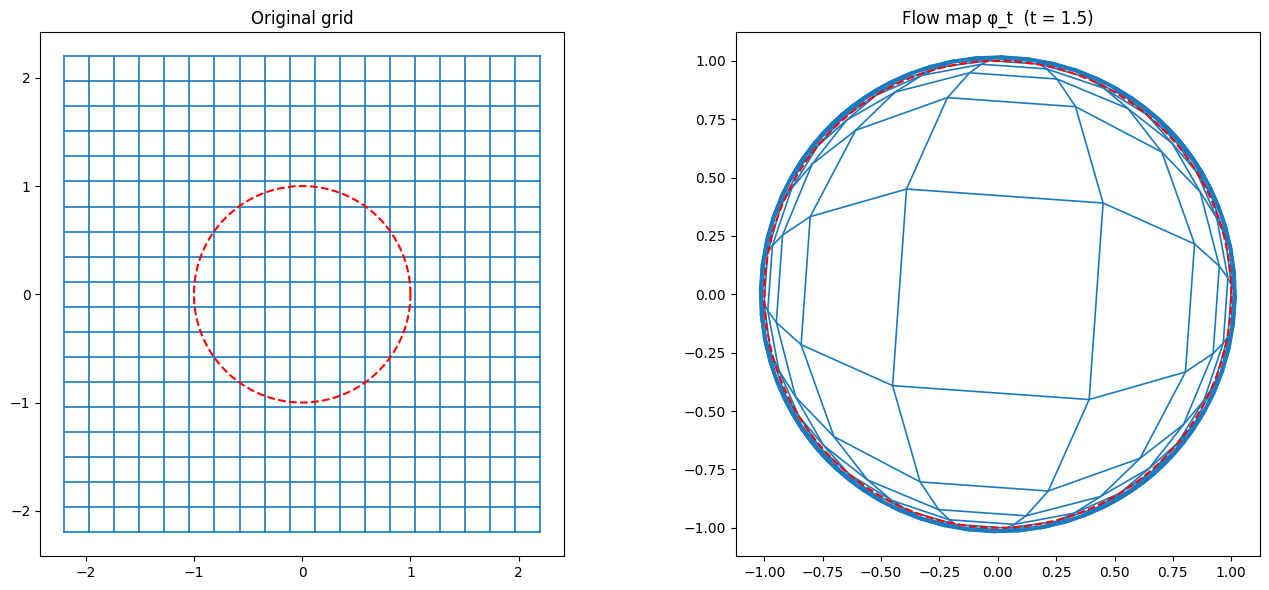

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def ode(t, y):
    x, yy = y
    r2 = x**2 + yy**2
    return [-yy + x*(1 - r2), x  + yy*(1 - r2)]

def flow(x0, y0, t):
    """Apply diffeomorphism φ_t to point (x0, y0)."""
    sol = solve_ivp(ode, [0, t], [x0, y0],
                    rtol=1e-9, atol=1e-12, dense_output=True)
    return sol.sol(t)   # returns [x(t), y(t)]

# Build uniform grid
N = 20
coords = np.linspace(-2.2, 2.2, N)

# Map every vertex through φ_t
T = 1.5
mapped = np.zeros((N, N, 2))
for i, x0 in enumerate(coords):
    for j, y0 in enumerate(coords):
        mapped[i, j] = flow(x0, y0, T)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (grid, title) in zip(axes, [
    (np.stack(np.meshgrid(coords, coords), -1).transpose(1,0,2), "Original grid"),
    (mapped, f"Flow map φ_t  (t = {T})")
]):
    # Draw rows and columns
    for j in range(N):
        ax.plot(grid[:, j, 0], grid[:, j, 1], color='#1a7abf', lw=1.2)
        ax.plot(grid[j, :, 0], grid[j, :, 1], color='#1a7abf', lw=1.2)
    ax.set_aspect('equal')
    ax.set_title(title)
    # Limit cycle
    th = np.linspace(0, 2*np.pi, 300)
    ax.plot(np.cos(th), np.sin(th), 'r--', lw=1.5, label='limit cycle')

plt.tight_layout()
plt.show()
#plt.savefig('diffeomorphism_grid.pdf', dpi=180, bbox_inches='tight')

# 4.2 1-D Example

<>:34: SyntaxWarning: invalid escape sequence '\d'
<>:34: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_13060/409497827.py:34: SyntaxWarning: invalid escape sequence '\d'
  fig.suptitle("Flow: $\dot{x} = sin(x)$", fontsize=14, y=1.02)


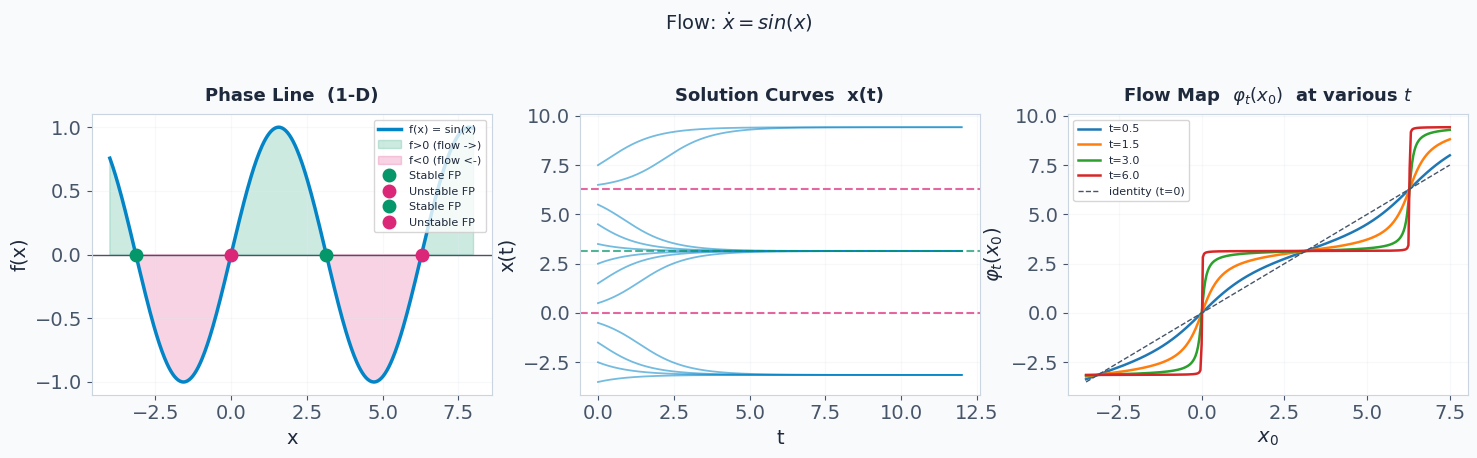

In [2]:

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
plt.rcParams.update({
    'figure.facecolor': '#f8fafc',
    'axes.facecolor':   '#ffffff',
    'axes.edgecolor':   '#cbd5e1',
    'axes.labelcolor':  '#1e293b',
    'xtick.color':      '#475569',
    'ytick.color':      '#475569',
    'text.color':       '#1e293b',
    'grid.color':       '#e2e8f0',
    'grid.alpha':       0.8,
    'lines.linewidth':  1.8,
    'font.family':      'DejaVu Sans',
    'font.size':        14,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.titlepad':    10,
})
PALETTE = ['#0284c7','#db2777','#059669','#ea580c','#7c3aed','#d97706','#dc2626','#0891b2']

    


    
def quiver_bg(ax, X, Y, U, V, cmap='cool'):
    speed = np.sqrt(U**2 + V**2)
    speed[speed == 0] = 1e-12
    ax.streamplot(X, Y, U, V, color=speed, cmap=cmap, linewidth=0.8, density=1.4, arrowsize=1.0)


fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Flow: $\dot{x} = sin(x)$", fontsize=14, y=1.02)

# Phase line
ax = axes[0]
ax.set_title("Phase Line  (1-D)")
x1 = np.linspace(-4, 8, 400)
f = np.sin(x1)
ax.axhline(0, color='#475569', lw=1)
ax.plot(x1, f, color=PALETTE[0], lw=2.5, label='f(x) = sin(x)')
ax.fill_between(x1, f, 0, where=f>0, alpha=0.2, color=PALETTE[2], label='f>0 (flow ->)')
ax.fill_between(x1, f, 0, where=f<0, alpha=0.2, color=PALETTE[1], label='f<0 (flow <-)')
fps = [k*np.pi for k in range(-1, 3)]
for fp in fps:
    stable = np.cos(fp) < 0
    ax.plot(fp, 0, 'o', ms=9, color=PALETTE[2] if stable else PALETTE[1],
            zorder=5, label='Stable FP' if stable else 'Unstable FP')
ax.set_xlabel('x'); ax.set_ylabel('f(x)')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

# Time series
ax = axes[1]
ax.set_title("Solution Curves  x(t)")
t_span = (0, 12); t_eval = np.linspace(*t_span, 500)
for x0 in np.linspace(-3.5, 7.5, 12):
    sol = solve_ivp(lambda t,x: [np.sin(x[0])], t_span, [x0], t_eval=t_eval, rtol=1e-8)
    ax.plot(sol.t, sol.y[0], color=PALETTE[0], alpha=0.55, lw=1.3)
for fp in [0, np.pi, 2*np.pi]:
    ax.axhline(fp, color=PALETTE[2] if np.cos(fp)<0 else PALETTE[1],
                lw=1.5, ls='--', alpha=0.7)
ax.set_xlabel('t'); ax.set_ylabel('x(t)')
ax.grid(True, alpha=0.3)

# Flow map phi_t
ax = axes[2]
ax.set_title("Flow Map  $\\varphi_t(x_0)$  at various $t$")
x0_vals = np.linspace(-3.5, 7.5, 300)
for t_fixed in [0.5, 1.5, 3.0, 6.0]:
    phi = []
    for x0 in x0_vals:
        sol = solve_ivp(lambda t,x: [np.sin(x[0])], (0, t_fixed), [x0], rtol=1e-8)
        phi.append(sol.y[0, -1])
    ax.plot(x0_vals, phi, lw=1.8, label=f't={t_fixed}')
ax.plot(x0_vals, x0_vals, '--', color='#475569', lw=1, label='identity (t=0)')
ax.set_xlabel('$x_0$'); ax.set_ylabel('$\\varphi_t(x_0)$')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()

fig.savefig('../Lectures/figures/one_dim_ode_flow_example.pdf', dpi=200, bbox_inches='tight', facecolor='white')


# 4.3 2-D Dynamical Systems Example

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_13060/1611070853.py:1: SyntaxWarning: invalid escape sequence '\p'
  """
/tmp/ipykernel_13060/1611070853.py:372: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


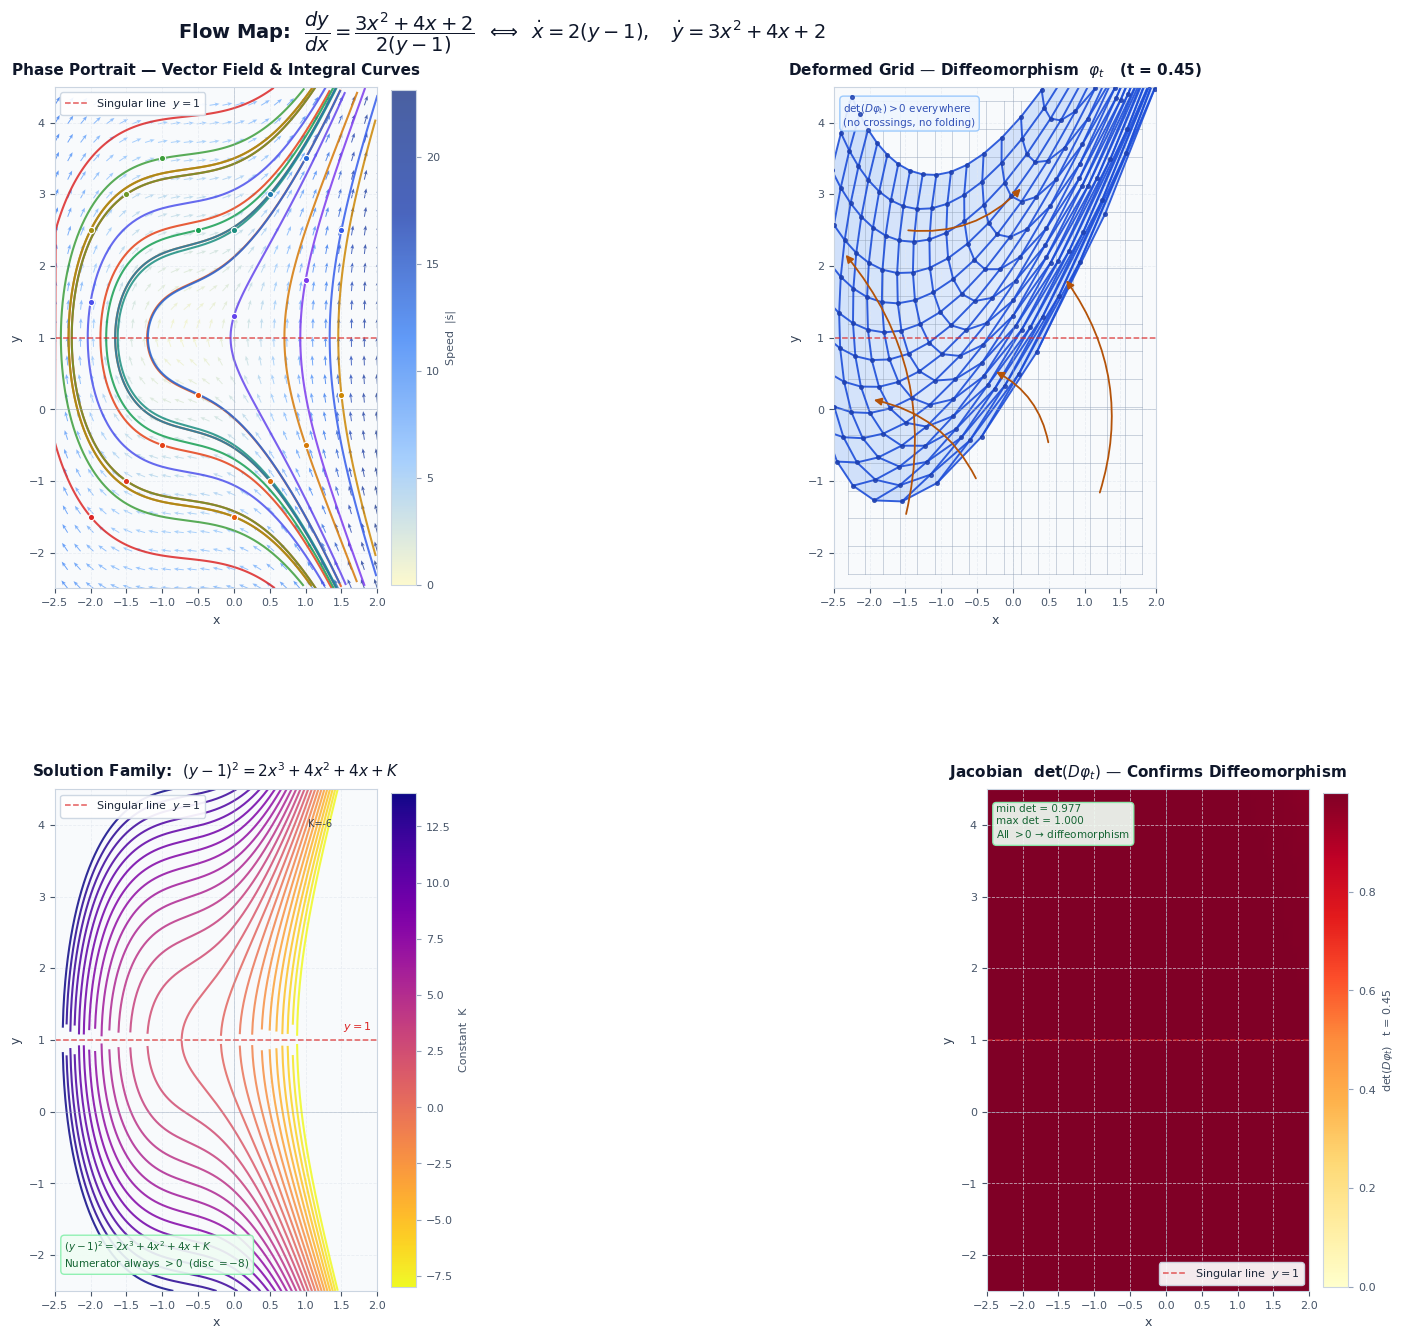

In [3]:
"""
Flow Map Visualization — Light Theme
=====================================
ODE:  dy/dx = (3x² + 4x + 2) / (2(y − 1))

Autonomous 2D system:
    dx/dt  =  2(y − 1)
    dy/dt  =  3x² + 4x + 2

Solution family:  (y − 1)² = 2x³ + 4x² + 4x + K

Panels
------
1. Phase portrait  — vector field + integral curves
2. Deformed grid   — diffeomorphism \phi _t of the flow map
3. Solution family — explicit curves (y−1)² = 2x³+4x²+4x+K
4. Jacobian heatmap — det(D\phi _t) confirms diffeomorphism
"""

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib.cm as cm
from scipy.integrate import solve_ivp


cmap_speed = LinearSegmentedColormap.from_list(
    'speed_light',
    ['#fef9c3', '#93c5fd', '#3b82f6', '#1e40af', '#1e3a8a'],
    N=512
)
# Integral curves: rich but readable on white
cmap_curves = LinearSegmentedColormap.from_list(
    'curves_light',
    ['#dc2626', '#ea580c', '#ca8a04', '#16a34a', '#2563eb', '#7c3aed'],
    N=256
)
# Solution family: sequential plasma-like on white
cmap_sol = LinearSegmentedColormap.from_list(
    'sol_light',
    ['#7c3aed', '#2563eb', '#0891b2', '#16a34a', '#ca8a04', '#dc2626'],
    N=256
)
# Jacobian heatmap: diverging, white at centre
cmap_det = LinearSegmentedColormap.from_list(
    'det_light',
    ['#991b1b', '#ef4444', '#fca5a5', '#ffffff', '#93c5fd', '#2563eb', '#1e3a8a'],
    N=512
)

#  ODE system 
def ode(t, state):
    x, y = state
    return [2.0 * (y - 1.0),
            3.0 * x**2 + 4.0 * x + 2.0]

def flow_pt(x0, y0, t):
    if abs(t) < 1e-10:
        return x0, y0
    sol = solve_ivp(ode, [0, t], [x0, y0],
                    method='RK45', rtol=1e-9, atol=1e-12)
    return sol.y[0, -1], sol.y[1, -1]

def jac_det(x0, y0, t, eps=1e-4):
    f0x, f0y = flow_pt(x0,     y0,     t)
    fex, fey = flow_pt(x0+eps, y0,     t)
    fyx, fyy = flow_pt(x0,     y0+eps, t)
    J00 = (fex - f0x) / eps;  J10 = (fey - f0y) / eps
    J01 = (fyx - f0x) / eps;  J11 = (fyy - f0y) / eps
    return J00*J11 - J01*J10

#  Domain & parameters 
XMIN, XMAX = -2.5,  2.0
YMIN, YMAX = -2.5,  4.5
T_FLOW = 0.45

#  Global light-theme rcParams 
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'figure.facecolor':  '#ffffff',
    'axes.facecolor':    '#f8fafc',       # very light blue-grey
    'axes.edgecolor':    '#94a3b8',
    'axes.linewidth':    0.8,
    'axes.labelcolor':   '#1e293b',
    'axes.titlecolor':   '#1e293b',
    'axes.titleweight':  'semibold',
    'axes.titlesize':    11,
    'axes.labelsize':    9,
    'text.color':        '#1e293b',
    'xtick.color':       '#475569',
    'ytick.color':       '#475569',
    'xtick.labelsize':   8,
    'ytick.labelsize':   8,
    'grid.color':        '#e2e8f0',
    'grid.linewidth':    0.6,
    'grid.linestyle':    '--',
    'legend.framealpha': 0.92,
    'legend.edgecolor':  '#cbd5e1',
    'legend.facecolor':  '#ffffff',
})

#  Figure 
fig = plt.figure(figsize=(18, 14), facecolor='white')

fig.text(
    0.5, 0.975,
    r'Flow Map:  $\dfrac{dy}{dx} = \dfrac{3x^2+4x+2}{2(y-1)}$'
    r'$\;\;\Longleftrightarrow\;\;$'
    r'$\dot{x} = 2(y-1),\quad \dot{y} = 3x^2+4x+2$',
    ha='center', va='top', fontsize=14, color='#0f172a',
    fontweight='semibold'
)

gs = gridspec.GridSpec(
    2, 2, figure=fig,
    hspace=0.40, wspace=0.32,
    left=0.06, right=0.97,
    top=0.92, bottom=0.06
)
axes = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(2)]

def style(ax, title):
    ax.set_title(title, pad=9, fontsize=11, color='#0f172a')
    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(YMIN, YMAX)
    ax.set_aspect('equal')
    ax.set_xlabel('x', fontsize=9, color='#334155')
    ax.set_ylabel('y', fontsize=9, color='#334155')
    ax.grid(True, alpha=0.7)
    # Singular line
    ax.axhline(1, color='#dc2626', lw=1.1, ls='--', alpha=0.75,
            label='Singular line  $y = 1$')
    # Faint zero-axes
    ax.axvline(0, color='#94a3b8', lw=0.5, alpha=0.6)
    ax.axhline(0, color='#94a3b8', lw=0.5, alpha=0.6)
    for spine in ax.spines.values():
        spine.set_color('#cbd5e1')

def style_cb(cb, label):
    cb.set_label(label, fontsize=8, color='#475569')
    cb.ax.yaxis.set_tick_params(labelcolor='#475569', color='#94a3b8')
    cb.outline.set_edgecolor('#cbd5e1')

# 
#  PANEL 1 — Phase portrait
# 
ax1 = axes[0]

# Vector field
nx, ny = 26, 28
xv = np.linspace(XMIN, XMAX, nx)
yv = np.linspace(YMIN, YMAX, ny)
Xv, Yv = np.meshgrid(xv, yv)
U = 2.0 * (Yv - 1.0)
V = 3.0*Xv**2 + 4.0*Xv + 2.0
speed = np.hypot(U, V)
U_n = U / (speed + 1e-6)
V_n = V / (speed + 1e-6)

qv = ax1.quiver(
    Xv, Yv, U_n, V_n, speed,
    cmap=cmap_speed, norm=Normalize(0, speed.max()),
    alpha=0.80, scale=32, width=0.003,
    headwidth=4, headlength=5, headaxislength=4
)
cb1 = plt.colorbar(qv, ax=ax1, fraction=0.035, pad=0.02)
style_cb(cb1, 'Speed  |ṡ|')

# Integral curves
ic_list = [
    (-2.0, -1.5), (-1.5, -1.0), (-1.0, -0.5), (-0.5,  0.2),
    ( 0.0, -1.5), ( 0.5, -1.0), ( 1.0, -0.5), ( 1.5,  0.2),
    (-2.0,  2.5), (-1.5,  3.0), (-1.0,  3.5), (-0.5,  2.5),
    ( 0.0,  2.5), ( 0.5,  3.0), ( 1.0,  3.5), ( 1.5,  2.5),
    (-2.0,  1.5), ( 0.0,  1.3), ( 1.0,  1.8),
]
colors_ic = cmap_curves(np.linspace(0, 1, len(ic_list)))

for (x0, y0), col in zip(ic_list, colors_ic):
    for sign in [1, -1]:
        sol = solve_ivp(
            ode, [0, sign * 3.5], [x0, y0],
            t_eval=np.linspace(0, sign * 3.5, 600),
            rtol=1e-9, atol=1e-12
        )
        xs, ys = sol.y
        mask = (xs >= XMIN) & (xs <= XMAX) & (ys >= YMIN) & (ys <= YMAX)
        ax1.plot(xs[mask], ys[mask], color=col, lw=1.5, alpha=0.85)
    ax1.plot(x0, y0, 'o', color=col, ms=4.5, zorder=5,
            markeredgecolor='white', markeredgewidth=0.8)

style(ax1, 'Phase Portrait — Vector Field & Integral Curves')
ax1.legend(fontsize=8, loc='upper left')

# 
#  PANEL 2 — Deformed grid (diffeomorphism \phi _t)
# 
ax2 = axes[1]

N_GRID = 18
gx = np.linspace(XMIN + 0.2, XMAX - 0.2, N_GRID)
gy = np.linspace(YMIN + 0.2, YMAX - 0.2, N_GRID)

# Integrate every grid vertex
M = np.zeros((N_GRID, N_GRID, 2))
for i, xi in enumerate(gx):
    for j, yj in enumerate(gy):
        M[i, j, 0], M[i, j, 1] = flow_pt(xi, yj, T_FLOW)

# Filled cells — light tint by distance from singular line
for i in range(N_GRID - 1):
    for j in range(N_GRID - 1):
        corners = [(i,j),(i+1,j),(i+1,j+1),(i,j+1)]
        pts = [M[ci, cj] for ci, cj in corners]
        r0 = np.hypot(gx[i], gy[j] - 1.0)
        hval = np.clip(r0 / 3.5, 0, 1)
        # light blue tint
        alpha_fill = 0.10 + hval * 0.12
        ax2.add_patch(plt.Polygon(pts, closed=True,
                                    facecolor='#3b82f6',
                                    alpha=alpha_fill,
                                    edgecolor='none'))

# Original grid (faint slate)
for j in range(N_GRID):
    ax2.plot(gx, [gy[j]]*N_GRID, color='#94a3b8', lw=0.65, alpha=0.5)
for i in range(N_GRID):
    ax2.plot([gx[i]]*N_GRID, gy,  color='#94a3b8', lw=0.65, alpha=0.5)

# Warped grid — strong blue
for j in range(N_GRID):
    ax2.plot(M[:, j, 0], M[:, j, 1], color='#1d4ed8', lw=1.4, alpha=0.9)
for i in range(N_GRID):
    ax2.plot(M[i, :, 0], M[i, :, 1], color='#1d4ed8', lw=1.4, alpha=0.9)

# Dots at warped vertices
ax2.scatter(M[:,:,0].ravel(), M[:,:,1].ravel(),
            c='#1e40af', s=7, zorder=4, alpha=0.8)

# Particle-path arrows (amber on white reads well)
arrow_ics = [(-1.5,-1.5),(-0.5,-1.0),(0.5,-0.5),(1.2,-1.2),
                (-1.5, 2.5),(-0.5, 3.0),(0.5, 3.5),(1.2, 2.8)]
for (x0, y0) in arrow_ics:
    x1, y1 = flow_pt(x0, y0, T_FLOW)
    ax2.annotate(
        "", xy=(x1, y1), xytext=(x0, y0),
        arrowprops=dict(
            arrowstyle="-|>", color='#b45309',
            lw=1.3, mutation_scale=11,
            connectionstyle='arc3,rad=0.25'
        )
    )

style(ax2, f'Deformed Grid — Diffeomorphism  $\\varphi_t$   (t = {T_FLOW})')
ax2.text(
    0.03, 0.97,
    'det$(D\\varphi_t) > 0$ everywhere\n(no crossings, no folding)',
    transform=ax2.transAxes, fontsize=7.5, va='top',
    color='#1e40af', alpha=0.9,
    bbox=dict(boxstyle='round,pad=0.35', fc='#eff6ff',
                ec='#93c5fd', alpha=0.9)
)

# 
#  PANEL 3 — Explicit solution family
# 
ax3 = axes[2]

x_sol = np.linspace(XMIN, XMAX, 1200)
K_vals = np.linspace(-8, 14, 24)
cmap_k = matplotlib.colormaps.get_cmap('plasma_r').resampled(len(K_vals))

for ki, K in enumerate(K_vals):
    rhs = 2*x_sol**3 + 4*x_sol**2 + 4*x_sol + K
    mask = rhs >= 0
    y_up = np.where(mask, 1 + np.sqrt(np.where(mask, rhs, 0)), np.nan)
    y_dn = np.where(mask, 1 - np.sqrt(np.where(mask, rhs, 0)), np.nan)
    col  = cmap_k(ki / (len(K_vals) - 1))
    for y_br in [y_up, y_dn]:
        in_range = (y_br >= YMIN) & (y_br <= YMAX)
        ax3.plot(x_sol, np.where(in_range, y_br, np.nan),
                    color=col, lw=1.5, alpha=0.85)

# K labels
for K, lx in [(-6, 1.2), (0, 1.65), (6, 1.85), (12, 0.9)]:
    rhs_l = 2*lx**3 + 4*lx**2 + 4*lx + K
    if rhs_l >= 0:
        y_l = 1 + np.sqrt(rhs_l)
        if YMIN < y_l < YMAX:
            ax3.text(lx, y_l + 0.14, f'K={K}',
                        fontsize=7, color='#334155', ha='center')

# Singular line (already added by style(), add annotation text)
ax3.text(XMAX - 0.08, 1.14, '$y = 1$', fontsize=8,
            color='#dc2626', ha='right')

# Annotation box
ax3.text(
    0.03, 0.04,
    r'$(y-1)^2 = 2x^3+4x^2+4x+K$' + '\n'
    r'Numerator always $> 0$  (disc $= -8$)',
    transform=ax3.transAxes, fontsize=7.5, va='bottom',
    color='#166534',
    bbox=dict(boxstyle='round,pad=0.35', fc='#f0fdf4',
                ec='#86efac', alpha=0.9)
)

sm3 = cm.ScalarMappable(cmap='plasma_r',
                            norm=Normalize(K_vals.min(), K_vals.max()))
sm3.set_array([])
cb3 = plt.colorbar(sm3, ax=ax3, fraction=0.035, pad=0.02)
style_cb(cb3, 'Constant  K')

style(ax3, r'Solution Family:  $(y-1)^2 = 2x^3+4x^2+4x+K$')
ax3.legend(fontsize=8, loc='upper left')

# 
#  PANEL 4 — Jacobian det(D\phi _t) heatmap
# 
ax4 = axes[3]

NJ = 40
xj = np.linspace(XMIN, XMAX, NJ)
yj = np.linspace(YMIN, YMAX, NJ)
Xj, Yj = np.meshgrid(xj, yj)
Dvals = np.full_like(Xj, np.nan)

for i in range(NJ):
    for j in range(NJ):
        try:
            Dvals[j, i] = jac_det(xj[i], yj[j], T_FLOW)
        except Exception:
            pass

Dclip = np.clip(Dvals, 0.0, 5.0)   # all positive; clip at 5 for display

im4 = ax4.pcolormesh(
    Xj, Yj, Dclip,
    cmap='YlOrRd',          # white-yellow-orange-red: light & clear
    shading='gouraud',
    norm=Normalize(0, Dclip[np.isfinite(Dclip)].max())
)

# Contour lines
cont = ax4.contour(Xj, Yj, Dvals,
                    levels=[0.5, 1.0, 1.5, 2.0, 3.0],
                    colors=['#334155'], linewidths=[0.75], alpha=0.6)
ax4.clabel(cont, fmt='%.1f', fontsize=7, colors='#1e293b')

cb4 = plt.colorbar(im4, ax=ax4, fraction=0.035, pad=0.02)
style_cb(cb4, f'det$(D\\varphi_t)$   t = {T_FLOW}')

valid = Dvals[np.isfinite(Dvals)]
ax4.text(
    0.03, 0.97,
    f'min det = {valid.min():.3f}\n'
    f'max det = {valid.max():.3f}\n'
    f'All $> 0$ → diffeomorphism',
    transform=ax4.transAxes, fontsize=7.5, va='top',
    color='#166534',
    bbox=dict(boxstyle='round,pad=0.35', fc='#f0fdf4',
                ec='#86efac', alpha=0.92)
)

style(ax4, 'Jacobian  det$(D\\varphi_t)$ — Confirms Diffeomorphism')
ax4.legend(fontsize=8, loc='lower right')

fig.savefig('../Lectures/figures/ode_flow_example.pdf', dpi=200, bbox_inches='tight', facecolor='white')

fig.show()


# 4.4 Phase portrait types

For $\dot{x} = Ax$ the solution is
$$
    x(t) = e^{At}\, x_0,
$$
where $x_0$ is the initial condition.  If $A$ is diagonalisable with
eigenvalues $\lambda_1, \lambda_2$ and corresponding eigenvectors
$v_1, v_2$, this expands to
$$
    x(t) = c_1\, e^{\lambda_1 t}\, v_1 + c_2\, e^{\lambda_2 t}\, v_2.
$$
So $\textbf{the eigenvalues control the growth or decay}$ of each component
of the solution.

```
U = A[0,0]*X + A[0,1]*Y
V = A[1,0]*X + A[1,1]*Y
```

This is the matrix-vector product $Ax$ evaluated at every grid point
$(x,y)$, giving the $\textbf{velocity field}$ $(\dot x,\dot y)$ at each
location.  $\texttt{streamplot}$ then draws flow lines tangent to this field.

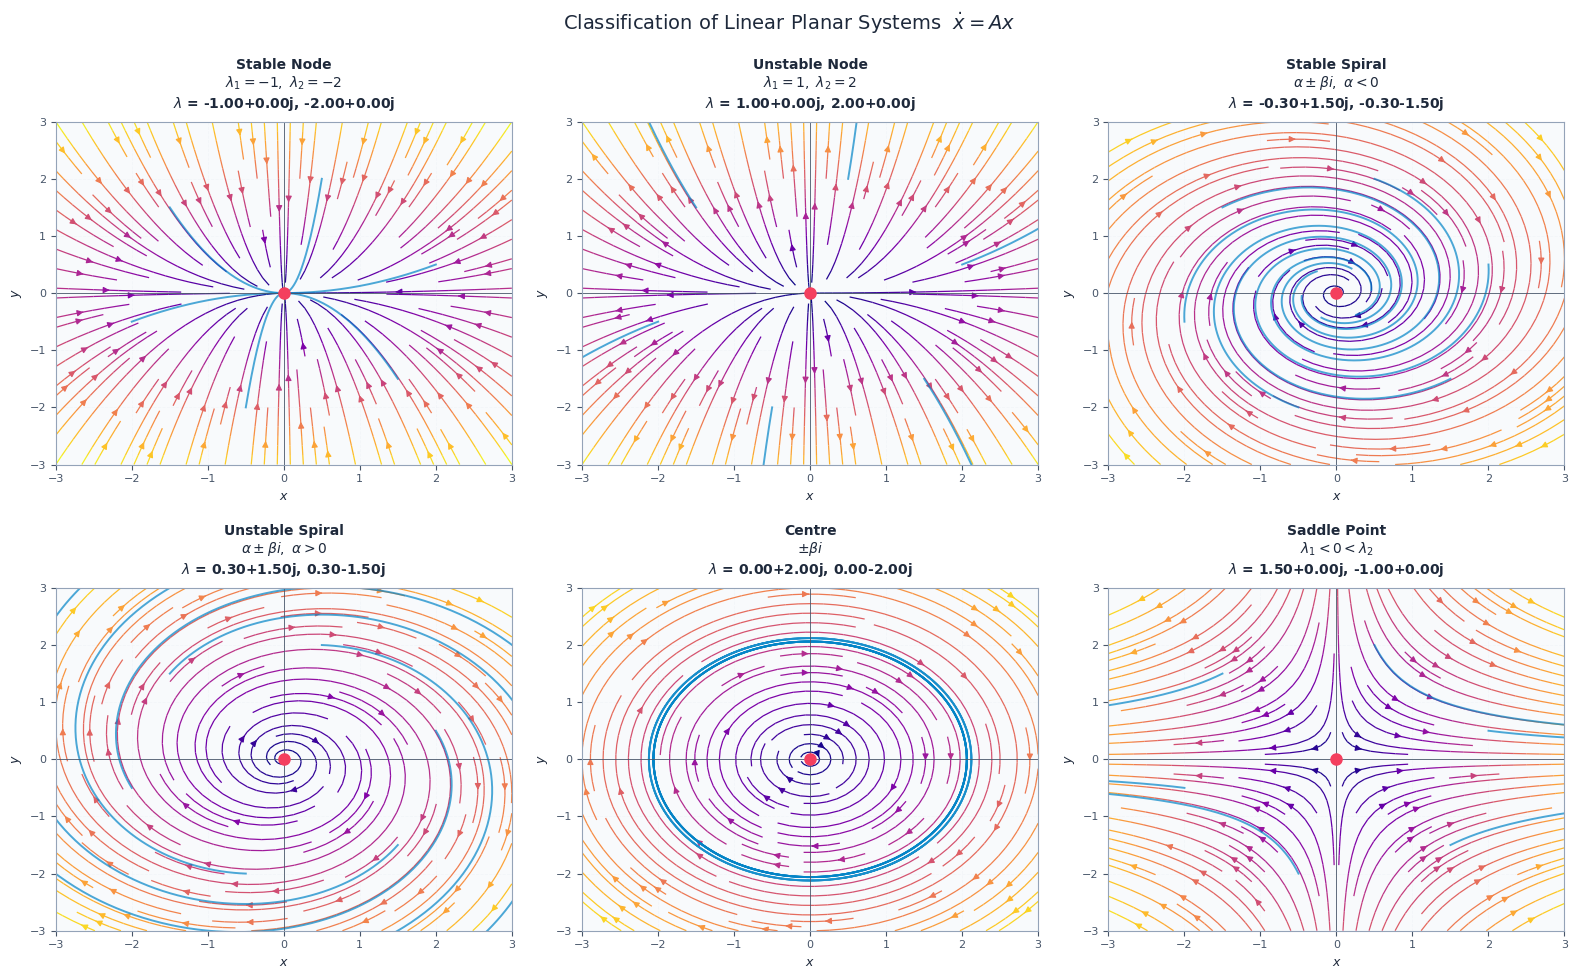

In [4]:
from scipy.linalg import eigvals

cases = [
    ("Stable Node\n$\\lambda_1=-1,\\ \\lambda_2=-2$",   [[-1,0],[0,-2]]),
    ("Unstable Node\n$\\lambda_1=1,\\ \\lambda_2=2$",    [[1,0],[0,2]]),
    ("Stable Spiral\n$\\alpha\\pm\\beta i,\\ \\alpha<0$", [[-0.3,1.5],[-1.5,-0.3]]),
    ("Unstable Spiral\n$\\alpha\\pm\\beta i,\\ \\alpha>0$",[[0.3,1.5],[-1.5,0.3]]),
    ("Centre\n$\\pm\\beta i$",                            [[0,2],[-2,0]]),
    ("Saddle Point\n$\\lambda_1<0<\\lambda_2$",           [[1.5,0],[0,-1.0]]),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(r"Classification of Linear Planar Systems  $\dot{x} = Ax$", fontsize=14)
axes = axes.flatten()

x_ = np.linspace(-3, 3, 22)
y_ = np.linspace(-3, 3, 22)
X, Y = np.meshgrid(x_, y_)

for i, (title, A) in enumerate(cases):
    ax = axes[i]
    A = np.array(A, dtype=float)
    U = A[0,0]*X + A[0,1]*Y
    V = A[1,0]*X + A[1,1]*Y
    speed = np.sqrt(U**2 + V**2)
    speed[speed==0] = 1e-12
    ax.streamplot(X, Y, U, V, color=speed, cmap='plasma',
                linewidth=0.9, density=1.2, arrowsize=0.9)

    # overlay a few trajectories
    for x0, y0 in [(2,0.5),(-2,-0.5),(0.5,2),(-0.5,-2),(1.5,-1.5),(-1.5,1.5)]:
        t_end = 5 if 'Spiral' in title or 'Centre' in title else 3
        sol = solve_ivp(lambda t,z: A@z, (0, t_end), [x0, y0],
                        t_eval=np.linspace(0, t_end, 600), rtol=1e-9)
        ax.plot(sol.y[0], sol.y[1], color=PALETTE[0], alpha=0.7, lw=1.4)
    ax.plot(0, 0, 'o', color='#f43f5e', ms=8, zorder=10)
    evals = eigvals(A)
    ax.set_title(f"{title}\n$\\lambda$ = {evals[0]:.2f}, {evals[1]:.2f}", fontsize=10)
    ax.set_xlim(-3,3); ax.set_ylim(-3,3)
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
    ax.grid(True, alpha=0.25)
    ax.axhline(0, color='#475569', lw=0.6)
    ax.axvline(0, color='#475569', lw=0.6)
    

plt.tight_layout()

fig.savefig('../Lectures/figures/ode_flow_phase_portrait.pdf', dpi=200, bbox_inches='tight', facecolor='white')


# 4.5 Nonlinear Pendulum

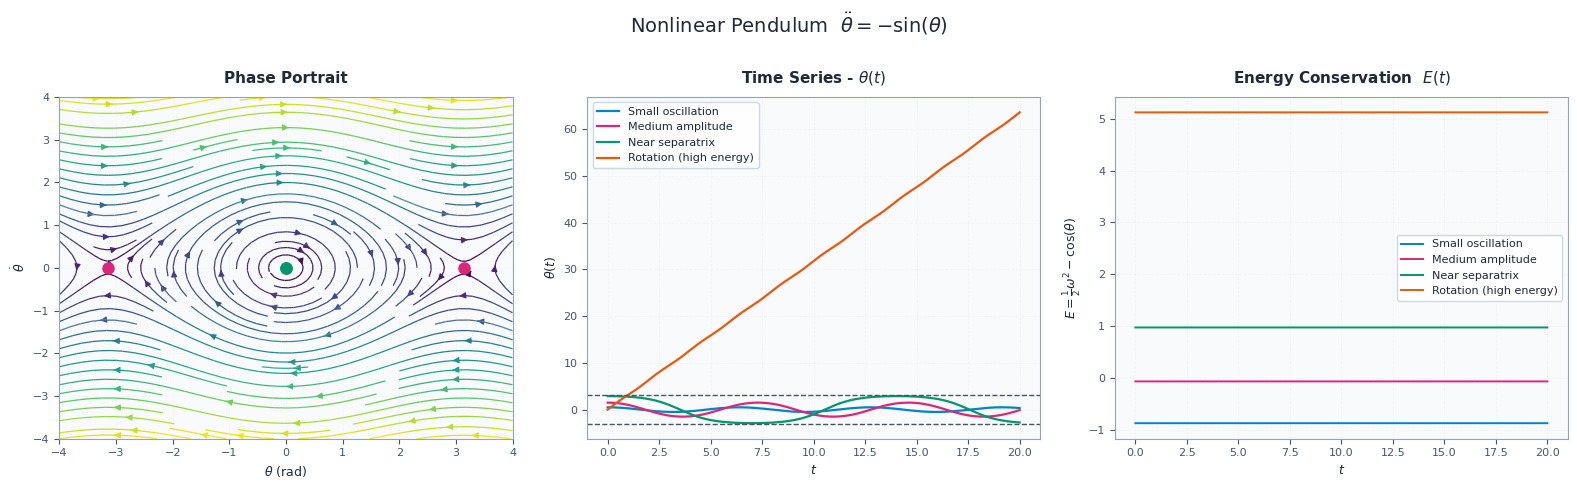

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(r"Nonlinear Pendulum  $\ddot{\theta} = -\sin(\theta)$", fontsize=14)

# Phase portrait
ax = axes[0]; ax.set_title("Phase Portrait")
th = np.linspace(-4, 4, 28)
om = np.linspace(-4, 4, 28)
TH, OM = np.meshgrid(th, om)
U2 = OM; V2 = -np.sin(TH)
speed = np.sqrt(U2**2+V2**2); speed[speed==0]=1e-12
ax.streamplot(TH, OM, U2, V2, color=speed, cmap='viridis',
            linewidth=0.9, density=1.3, arrowsize=0.9)

# energy contours
th_c = np.linspace(-4,4,400); om_c = np.linspace(-4,4,400)
THc, OMc = np.meshgrid(th_c, om_c)
E = 0.5*OMc**2 - np.cos(THc)
cs = ax.contour(THc, OMc, E, levels=np.linspace(-1, 3, 20),
                colors='white', alpha=0.25, linewidths=0.6)
ax.plot([-np.pi, np.pi],[0,0], 'o', ms=8, color=PALETTE[1], zorder=5)
ax.plot([0,0],[0,0], 'o', ms=8, color=PALETTE[2], zorder=5)
ax.set_xlabel(r'$\theta$ (rad)'); ax.set_ylabel(r'$\dot{\theta}$')
ax.grid(True, alpha=0.25)

# time series for different energies
ax = axes[1]; ax.set_title(r"Time Series - $\theta(t)$")
t_span2 = (0, 20); t_eval2 = np.linspace(0, 20, 2000)
ics = [(0.5, 0, 'Small oscillation'),
        (1.5, 0, 'Medium amplitude'),
        (2.9, 0, 'Near separatrix'),
        (0,   3.5, 'Rotation (high energy)')]
for (th0, om0, lab), col in zip(ics, PALETTE):
    sol = solve_ivp(lambda t,z: [z[1], -np.sin(z[0])],
                    t_span2, [th0, om0], t_eval=t_eval2, rtol=1e-10)
    ax.plot(sol.t, sol.y[0], color=col, lw=1.6, label=lab)
ax.axhline(np.pi,  color='#475569', ls='--', lw=1)
ax.axhline(-np.pi, color='#475569', ls='--', lw=1)
ax.set_xlabel('$t$'); ax.set_ylabel(r'$\theta(t)$'); ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Energy vs time
ax = axes[2]; ax.set_title(r"Energy Conservation  $E(t)$")
for (th0, om0, lab), col in zip(ics, PALETTE):
    sol = solve_ivp(lambda t,z: [z[1], -np.sin(z[0])],
                    t_span2, [th0, om0], t_eval=t_eval2, rtol=1e-10)
    E_t = 0.5*sol.y[1]**2 - np.cos(sol.y[0])
    ax.plot(sol.t, E_t, color=col, lw=1.4, label=lab)
ax.set_xlabel('$t$')
ax.set_ylabel(r'$E = \frac{1}{2}\omega^2 - \cos(\theta)$')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()

fig.savefig('../Lectures/figures/nonlinear_pendulum.pdf', dpi=200, bbox_inches='tight', facecolor='white')


# 4.6 Van der Pol Oscillator

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_13060/1754481766.py:9: SyntaxWarning: invalid escape sequence '\m'
  ax = axes[0]; ax.set_title("Phase Portrait  $\mu=2$")
/tmp/ipykernel_13060/1754481766.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax = axes[1]; ax.set_title("Limit Cycles for $\mu = 0.5, 1, 2, 4$")
/tmp/ipykernel_13060/1754481766.py:35: SyntaxWarning: invalid escape sequence '\m'
  ax = axes[2]; ax.set_title("Time Series  $x(t)$ for $\mu = 0.1, 1, 5$")
/tmp/ipykernel_13060/1754481766.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(sol.t, sol.y[0], color=col, lw=1.6, label=f'$\mu$={mu

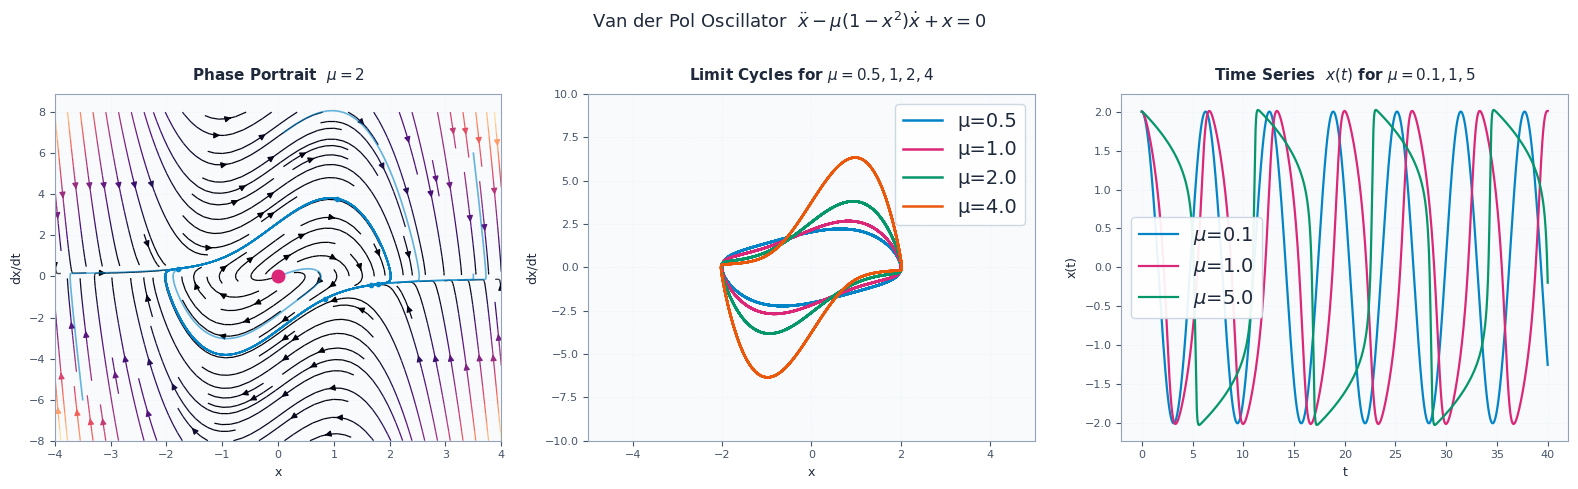

In [9]:
def vdp(t, z, mu):
    x, y = z
    return [y, mu*(1-x**2)*y - x]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(r"Van der Pol Oscillator  $\ddot{x} - \mu(1-x^2)\dot{x} + x = 0$", fontsize=13)

# Phase portrait for mu=2
ax = axes[0]; ax.set_title("Phase Portrait  $\mu=2$")
mu = 2.0
xv = np.linspace(-4,4,28); yv = np.linspace(-8,8,28)
XV, YV = np.meshgrid(xv, yv)
UV = YV; VV = mu*(1-XV**2)*YV - XV
speed = np.sqrt(UV**2+VV**2); speed[speed==0]=1e-12
ax.streamplot(XV, YV, UV, VV, color=speed, cmap='magma',
                linewidth=0.9, density=1.2, arrowsize=0.9)
for x0, y0 in [(0.1,0.1),(3.5,0.1),(0.1,7),(3.5,6),(-3.5,-6)]:
    sol = solve_ivp(lambda t,z: vdp(t,z,mu), (0,40), [x0,y0],
                    t_eval=np.linspace(0,40,4000), rtol=1e-9)
    ax.plot(sol.y[0], sol.y[1], color=PALETTE[0], alpha=0.6, lw=1.2)
    ax.plot(sol.y[0,-1], sol.y[1,-1], 'o', color=PALETTE[0], ms=3)
ax.plot(0, 0, 'o', ms=9, color=PALETTE[1], zorder=10)
ax.set_xlabel('x'); ax.set_ylabel('dx/dt'); ax.grid(True, alpha=0.25)

# Limit cycles for various mu
ax = axes[1]; ax.set_title("Limit Cycles for $\mu = 0.5, 1, 2, 4$")
for mu_val, col in zip([0.5, 1.0, 2.0, 4.0], PALETTE):
    sol = solve_ivp(lambda t,z: vdp(t,z,mu_val), (0,100), [0.1, 0.1],
                    t_eval=np.linspace(50, 100, 5000), rtol=1e-9)
    ax.plot(sol.y[0], sol.y[1], color=col, lw=1.8, label=f'μ={mu_val}')
ax.set_xlabel('x'); ax.set_ylabel('dx/dt')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xlim(-5,5); ax.set_ylim(-10,10)

# Time series comparison
ax = axes[2]; ax.set_title("Time Series  $x(t)$ for $\mu = 0.1, 1, 5$")
t_ev = np.linspace(0, 40, 4000)
for mu_val, col in zip([0.1, 1.0, 5.0], PALETTE[:3]):
    sol = solve_ivp(lambda t,z: vdp(t,z,mu_val), (0,40), [2, 0],
                    t_eval=t_ev, rtol=1e-9)
    ax.plot(sol.t, sol.y[0], color=col, lw=1.6, label=f'$\mu$={mu_val}')
ax.set_xlabel('t'); ax.set_ylabel('x(t)')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()

fig.savefig('../Lectures/figures/vanderpol_limitcycle.pdf', dpi=200, bbox_inches='tight', facecolor='white')


# 4.7 Bifuraction Diagram

<>:29: SyntaxWarning: invalid escape sequence '\d'
<>:29: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_13060/3508085253.py:29: SyntaxWarning: invalid escape sequence '\d'
  ax = axes[0,2]; ax.set_title("Pitchfork (supercritical)  $\dot{x} = rx - x^3$")


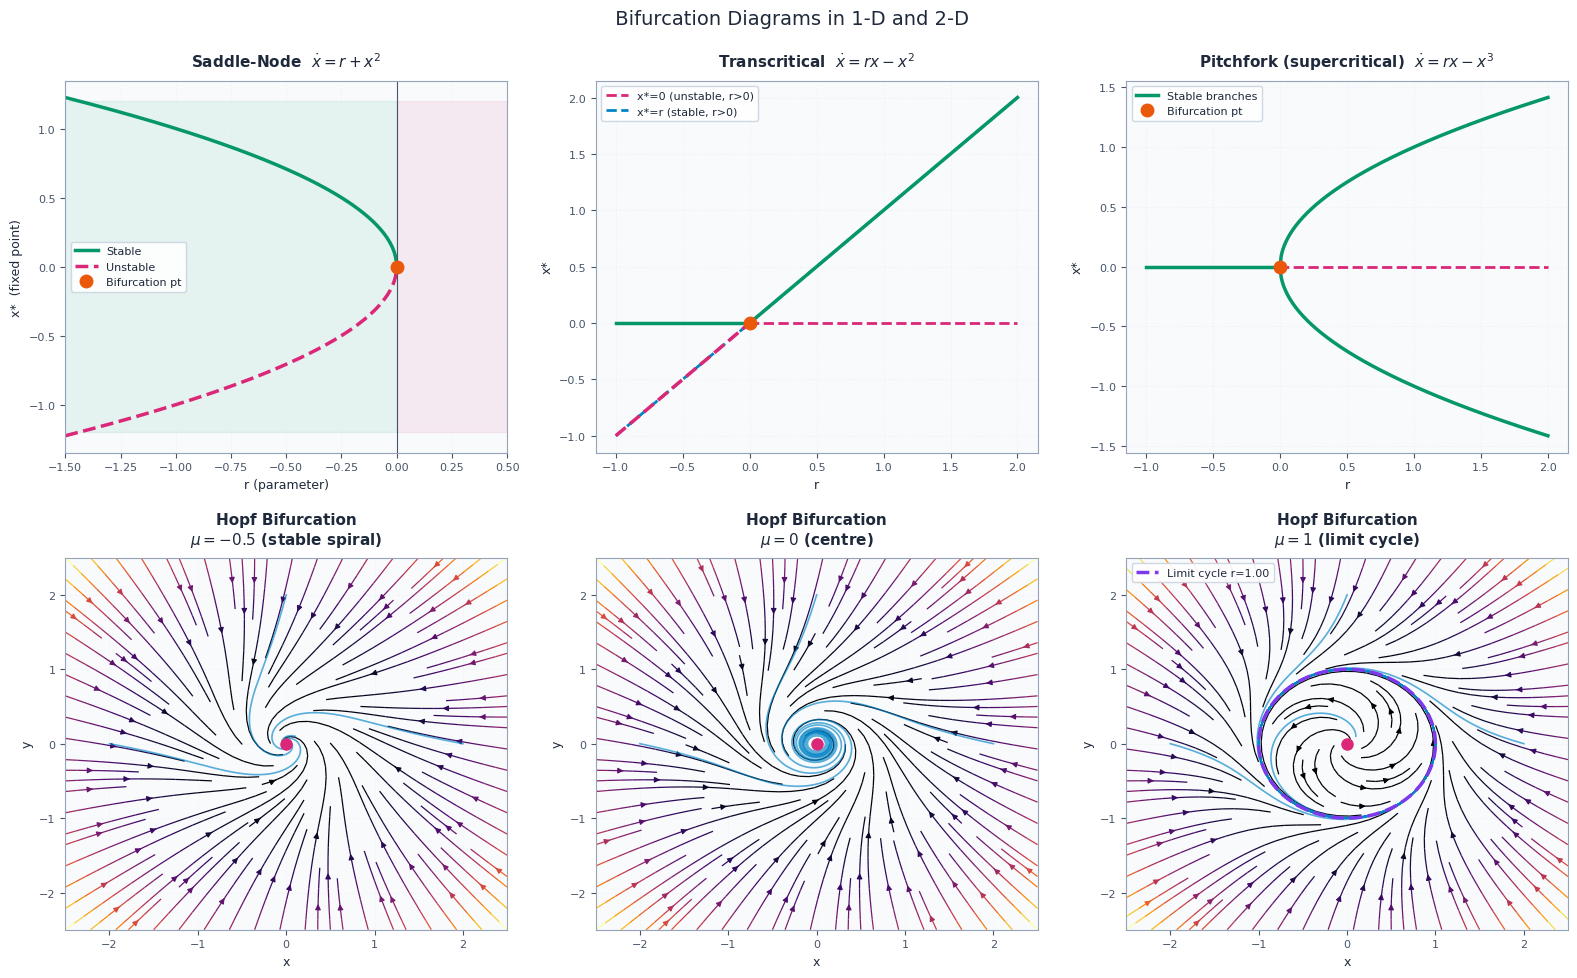

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(" Bifurcation Diagrams in 1-D and 2-D", fontsize=14)

# Saddle-node bifurcation
ax = axes[0,0]; ax.set_title(r"Saddle-Node  $\dot{x} = r + x^2$")
r_vals = np.linspace(-1.5, 0.5, 400)
ax.fill_betweenx(np.linspace(-1.2,1.2,2), -1.5, 0, alpha=0.08, color=PALETTE[2])
ax.fill_betweenx(np.linspace(-1.2,1.2,2), 0, 0.5,  alpha=0.08, color=PALETTE[1])
r_neg = r_vals[r_vals <= 0]
ax.plot(r_neg, np.sqrt(-r_neg), color=PALETTE[2], lw=2.5, label='Stable')
ax.plot(r_neg, -np.sqrt(-r_neg), '--', color=PALETTE[1], lw=2.5, label='Unstable')
ax.plot(0, 0, 'o', ms=9, color=PALETTE[3], zorder=10, label='Bifurcation pt')
ax.axvline(0, color='#475569', lw=0.8)
ax.set_xlabel('r (parameter)'); ax.set_ylabel('x*  (fixed point)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_xlim(-1.5, 0.5)

# Transcritical bifurcation
ax = axes[0,1]; ax.set_title(r"Transcritical  $\dot{x} = rx - x^2$")
r_v = np.linspace(-1, 2, 400)
ax.plot(r_v, np.zeros_like(r_v), '--', color=PALETTE[1], lw=2, label='x*=0 (unstable, r>0)')
ax.plot(r_v[r_v<=0], np.zeros_like(r_v[r_v<=0]), color=PALETTE[2], lw=2.5)
ax.plot(r_v, r_v, '--', color=PALETTE[0], lw=2, label='x*=r (stable, r>0)')
ax.plot(r_v[r_v<=0], r_v[r_v<=0], color=PALETTE[1], lw=2.5, ls='--')
ax.plot(r_v[r_v>=0], r_v[r_v>=0], color=PALETTE[2], lw=2.5)
ax.plot(0, 0, 'o', ms=9, color=PALETTE[3], zorder=10)
ax.set_xlabel('r'); ax.set_ylabel("x*"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Pitchfork (supercritical)
ax = axes[0,2]; ax.set_title("Pitchfork (supercritical)  $\dot{x} = rx - x^3$")
r_v = np.linspace(-1, 2, 400)
ax.plot(r_v, np.zeros_like(r_v), '--', color=PALETTE[1], lw=2)
ax.plot(r_v[r_v<=0], np.zeros_like(r_v[r_v<=0]), color=PALETTE[2], lw=2.5)
r_pos = r_v[r_v >= 0]
ax.plot(r_pos, np.sqrt(r_pos), color=PALETTE[2], lw=2.5, label='Stable branches')
ax.plot(r_pos, -np.sqrt(r_pos), color=PALETTE[2], lw=2.5)
ax.plot(0, 0, 'o', ms=9, color=PALETTE[3], zorder=10, label='Bifurcation pt')
ax.set_xlabel('r'); ax.set_ylabel("x*"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Hopf bifurcation phase portraits
for col_idx, (mu_val, label, col2) in enumerate(
            [(-0.5,r'$\mu=-0.5$ (stable spiral)',2),
            (0.0, r'$\mu=0$ (centre)',3),
            (1.0, r'$\mu=1$ (limit cycle)',4)]):
    ax = axes[1, col_idx]
    ax.set_title(f"Hopf Bifurcation\n{label}")
    # \xdot = mu x - y - x(x^2+y^2),  \ydot = x + \mu y - y(x^2+y^2)
    xv = np.linspace(-2.5, 2.5, 22); yv = np.linspace(-2.5, 2.5, 22)
    XV, YV = np.meshgrid(xv, yv)
    r2 = XV**2 + YV**2
    UV = mu_val*XV - YV - XV*r2
    VV = XV + mu_val*YV - YV*r2
    sp = np.sqrt(UV**2+VV**2); sp[sp==0]=1e-12
    ax.streamplot(XV, YV, UV, VV, color=sp, cmap='inferno',
                    linewidth=0.9, density=1.2, arrowsize=0.8)
    for x0,y0 in [(2,0),(0.1,0.1),(-2,0),(0,2)]:
        sol = solve_ivp(lambda t,z: [mu_val*z[0]-z[1]-z[0]*(z[0]**2+z[1]**2),
                                        z[0]+mu_val*z[1]-z[1]*(z[0]**2+z[1]**2)],
                        (0,25), [x0,y0], t_eval=np.linspace(0,25,2500), rtol=1e-9)
        ax.plot(sol.y[0], sol.y[1], color=PALETTE[0], alpha=0.65, lw=1.2)
    if mu_val > 0:
        theta = np.linspace(0, 2*np.pi, 200)
        ax.plot(np.sqrt(mu_val)*np.cos(theta), np.sqrt(mu_val)*np.sin(theta),
                color=PALETTE[4], lw=2.5, ls='--', label=f'Limit cycle r={np.sqrt(mu_val):.2f}')
        ax.legend(fontsize=8)
    ax.plot(0,0,'o', ms=8, color=PALETTE[1], zorder=10)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_xlim(-2.5,2.5); ax.set_ylim(-2.5,2.5)
    ax.grid(True, alpha=0.25)

plt.tight_layout()

fig.savefig('../Lectures/figures/bifurcation.pdf', dpi=200, bbox_inches='tight', facecolor='white')

# 5. Stochastic Differential Equations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from scipy.ndimage import gaussian_filter1d

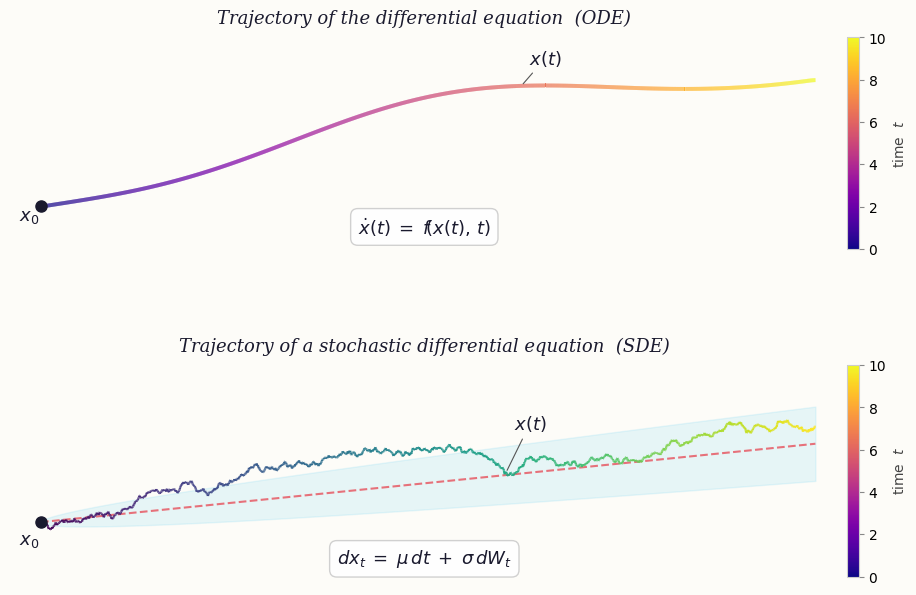

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), facecolor="#fdfcf8")
fig.subplots_adjust(hspace=0.55)

T   = 10.0
N   = 2000
dt  = T / N
t   = np.linspace(0, T, N)

ax1 = axes[0]
ax1.set_facecolor("#fdfcf8")

# function
ax1 = axes[0]
ax1.set_facecolor("#fdfcf8")

# Craft a visually appealing smooth "S-like" path
x_ode = (0.18 * t                             # gentle drift
         - 0.04 * np.sin(1.1 * t)             # first undulation
         + 0.30 * np.sin(0.45 * t - 0.6)     # broad wave
         + 0.12 * np.cos(0.9  * t + 1.0))    # secondary ripple

# Smooth once more for absolute cleanliness
x_ode = gaussian_filter1d(x_ode, sigma=8)

# Colour gradient along the path (blue → orange)
from matplotlib.collections import LineCollection
points  = np.array([t, x_ode]).T.reshape(-1, 1, 2)
segs    = np.concatenate([points[:-1], points[1:]], axis=1)
cmap1   = plt.get_cmap("plasma")
lc1     = LineCollection(segs, cmap=cmap1, linewidth=2.8, zorder=3)
lc1.set_array(t[:-1])
ax1.add_collection(lc1)

# Start / end markers
ax1.plot(t[0],  x_ode[0],  'o', color="#1a1a2e", ms=8,  zorder=5)


# Labels  x₀  and  x(t)
ax1.text(t[0] - 0.15, x_ode[0] - 0.18, r"$x_0$",
        fontsize=13, color="#1a1a2e", ha="center")
ax1.annotate(r"$x(t)$",
                xy=(t[int(0.62*N)], x_ode[int(0.62*N)]),
                xytext=(t[int(0.62*N)] + 0.1, x_ode[int(0.62*N)] + 0.28),
                fontsize=13, color="#1a1a2e",
                arrowprops=dict(arrowstyle="-", color="#555555", lw=0.8))

ax1.set_xlim(-0.4, T + 0.3)
ax1.set_ylim(x_ode.min() - 0.55, x_ode.max() + 0.55)
ax1.axis("off")

ax1.set_title("Trajectory of the differential equation  (ODE)",
                fontsize=13, color="#1a1a2e", pad=10,
                fontfamily="serif", style="italic")

# Colour-bar hint
sm1 = plt.cm.ScalarMappable(cmap=cmap1, norm=plt.Normalize(0, T))
sm1.set_array([])
cb1 = fig.colorbar(sm1, ax=ax1, orientation="vertical",
                fraction=0.018, pad=0.01, aspect=18)
cb1.set_label("time  $t$", fontsize=10, color="#444")
cb1.ax.yaxis.set_tick_params(color="#888")
cb1.outline.set_edgecolor("#cccccc")


# SDE
ax2 = axes[1]
ax2.set_facecolor("#fdfcf8")

# Euler-Maruyama:  dX = \mu dt + \sigma dW
mu    = 0.10
sigma = 0.15
X     = np.zeros(N)
X[0]  = 0.0
dW    = np.random.normal(0, np.sqrt(dt), N - 1)
for i in range(N - 1):
    X[i+1] = X[i] + mu * dt + sigma * dW[i]

# Colour gradient (teal → crimson)
cmap2   = plt.get_cmap("viridis")
points2 = np.array([t, X]).T.reshape(-1, 1, 2)
segs2   = np.concatenate([points2[:-1], points2[1:]], axis=1)
lc2     = LineCollection(segs2, cmap=cmap2, linewidth=1.6, zorder=3, alpha=0.92)
lc2.set_array(t[:-1])
ax2.add_collection(lc2)

mean_env = mu * t
std_env  = sigma * np.sqrt(t + 1e-9)
ax2.fill_between(t, mean_env - std_env, mean_env + std_env,
                color="#4cc9f0", alpha=0.13, zorder=1, label=r"$\pm\,\sigma\sqrt{t}$ envelope")
ax2.plot(t, mean_env, "--", color="#e63946", lw=1.5,
                alpha=0.7, zorder=2, label=r"drift  $\mu t$")

# Start / end markers
ax2.plot(t[0],  X[0],  'o', color="#1a1a2e", ms=8,  zorder=5)


# Labels
ax2.text(t[0] - 0.15, X[0] - 0.28, r"$x_0$",
        fontsize=13, color="#1a1a2e", ha="center")
ax2.annotate(r"$x(t)$",
                xy=(t[int(0.60*N)], X[int(0.60*N)]),
                xytext=(t[int(0.60*N)] + 0.1, X[int(0.60*N)] + 0.55),
                fontsize=13, color="#1a1a2e",
                arrowprops=dict(arrowstyle="-", color="#555555", lw=0.8))

ax2.set_xlim(-0.4, T + 0.3)
ax2.set_ylim(X.min() - 0.6, X.max() + 0.7)
ax2.axis("off")

ax2.set_title("Trajectory of a stochastic differential equation  (SDE)",
                fontsize=13, color="#1a1a2e", pad=10,
                fontfamily="serif", style="italic")

# Colour-bar hint
sm2 = plt.cm.ScalarMappable(cmap=cmap1, norm=plt.Normalize(0, T))
sm2.set_array([])
cb2 = fig.colorbar(sm2, ax=ax2, orientation="vertical",
                fraction=0.018, pad=0.01, aspect=18)
cb2.set_label("time  $t$", fontsize=10, color="#444")
cb2.ax.yaxis.set_tick_params(color="#888")
cb2.outline.set_edgecolor("#cccccc")

ax2.text(0.50, 0.06,
        r"$dx_t \;=\; \mu\,dt \;+\; \sigma\,dW_t$",
        transform=ax2.transAxes,
        fontsize=13, color="#1a1a2e", ha="center",
        bbox=dict(boxstyle="round,pad=0.4", fc="#ffffff",
                ec="#cccccc", alpha=0.9))

ax1.text(0.50, 0.07,
        r"$\dot{x}(t) \;=\; f\!\left(x(t),\,t\right)$",
        transform=ax1.transAxes,
        fontsize=13, color="#1a1a2e", ha="center",
        bbox=dict(boxstyle="round,pad=0.4", fc="#ffffff",
                ec="#cccccc", alpha=0.9))

fig.savefig('../Lectures/figures/ode_sde_comparison.pdf', dpi=200, bbox_inches='tight', facecolor='white')
